# Two-axion photon spectra

**Counting axions with IAXO** — B. Grinstein, C. Miró, P. Quílez (arXiv:2606.XXXXX). 

Compares the X-ray spectra expected at IAXO for different two-axion scenarios:
quasi-degenerate, hierarchical, and generic mass ratio, against the single-axion
hypotheses (massless and massive).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'unbinned')))  # load shared modules from unbinned/

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from spectra_functions import plot_spectrum_comparison, plot_spectrum_ratio, sci_label

# save the spectra figures into this folder's plots/ (not unbinned/plots)
import spectra_functions
spectra_functions.PLOT_DIR = os.path.join(os.getcwd(), 'plots')

### Spectrum configuration dictionaries

Each curve is defined by a small dictionary passed to `plot_spectrum_comparison`.
The two axion masses can be given in several equivalent ways, and the remaining keys
control the line style:

| key | meaning |
|-----|---------|
| `m1`, `m2` | axion masses [eV] (`m1=m2` $\to$ single massive axion, `m1=m2=0` $\to$ massless) |
| `sqrt_dm2` | give this together with `m1` (or 0) instead of `m2`: sets $m_2=\sqrt{m_1^2+\Delta m_{21}^2}$ |
| `r` | mass ratio $m_2/m_1$ (give together with `m1`) |
| `label` | legend entry (LaTeX allowed; use `'_nolegend_'` to hide a curve from the legend) |
| `color`, `lw`, `ls`, `alpha`, `zorder` | matplotlib line styling |

The mixing angle is fixed to $\varphi=\pi/4$ (equal photon couplings). The detector
resolution $\omega_{\rm res}$ is the `E_res_keV` argument of the call (common to all
curves in that call), and `normalize=True` rescales every spectrum to the same area, so
the comparison shows only the spectral *shape*.

## Quasi-degenerate regime

Paper benchmark: $m_2 = 10^{-3}$ eV, $\sqrt{\Delta m_{21}^2} = 7\times 10^{-7}$ eV, $\varphi = \pi/4$.
The cosine modulation from the mass splitting distorts the spectrum relative to a single
(massless) axion. We plot the *same* two-axion spectrum smeared at three detector
resolutions $\omega_{\rm res} = 10,\,100,\,200$ eV: increasing $\omega_{\rm res}$
progressively washes out the oscillation, which is why the energy resolution is the key
handle for discrimination in this regime.

Saved: /home/pabloql/Cloud/ownCloud/MineOwnCountingAxionIAXO/counting-axions-iaxo/spectra/plots/spectra_quasi_degenerate.pdf/.png


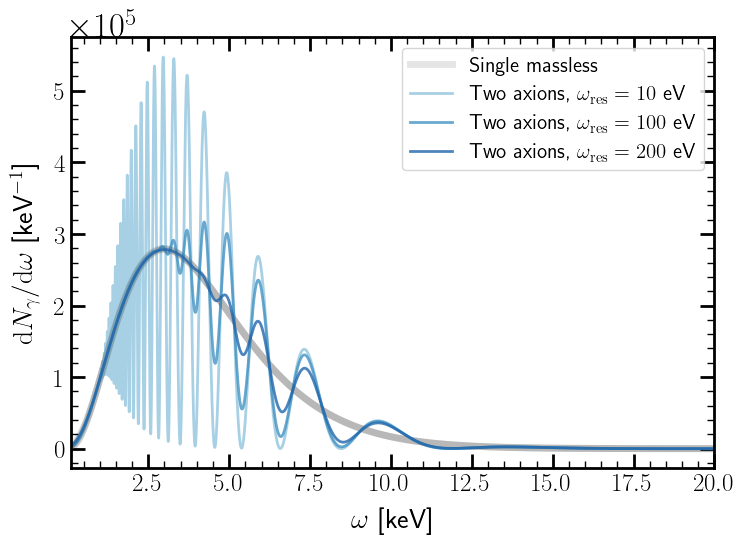

In [3]:
# Same quasi-degenerate two-axion spectrum (draft benchmark), smeared at three
# detector resolutions. Only omega_res (E_res_keV) changes between the curves.
res_list   = [0.01, 0.1, 0.2]                    # omega_res [keV] = 10, 100, 200 eV
res_colors = ['#92c5de', '#4393c3', '#2166ac']   # light -> dark blue

ax = None
for i, (E_res, col) in enumerate(zip(res_list, res_colors)):
    configs_qd = [
        # single massless axion baseline (shown once in the legend)
        {'label': 'Single massless' if i == 0 else '_nolegend_',
         'm1': 0, 'm2': 0, 'color': 'k', 'lw': 5, 'alpha': 0.1},
        # two-axion quasi-degenerate spectrum at this resolution
        {'label': rf'Two axions, $\omega_{{\rm res}} = {int(E_res*1000)}$ eV',
         'm2': 1e-3, 'sqrt_dm2': 7e-7, 'color': col},
    ]
    fig, ax = plot_spectrum_comparison(
        configs_qd, E_res_keV=E_res, n_uniform=100000, normalize=True,
        save_name='spectra_quasi_degenerate' if i == len(res_list) - 1 else None,
        ax=ax)
plt.show()

## Hierarchical regime

Paper benchmark: $m_1 = 0$, $\sqrt{\Delta m_{21}^2} \simeq m_2 = 1.5\times 10^{-2}$ eV, $\varphi = \pi/4$.
The two-axion spectrum differs from the best-fit single massive axion
($m \simeq 1.12\times 10^{-2}$ eV) through an overall shape distortion and a peak shift.
Unlike the quasi-degenerate case, this difference is *not* washed out by finite energy
resolution, so a single representative $\omega_{\rm res} = 100$ eV is shown.

Saved: /home/pabloql/Cloud/ownCloud/MineOwnCountingAxionIAXO/counting-axions-iaxo/spectra/plots/spectra_hierarchical.pdf/.png


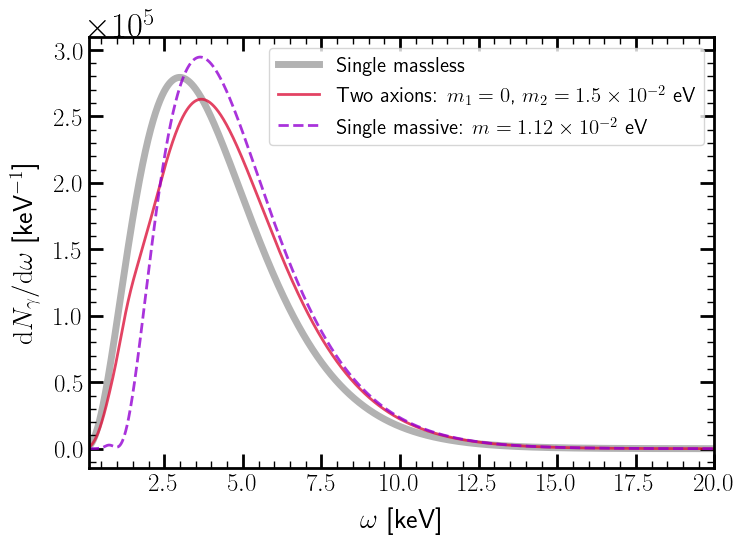

In [3]:
configs_hier = [
    {'label': 'Single massless', 'm1': 0, 'm2': 0, 'color': 'k', 'lw': 5, 'alpha': 0.3},
    {'label': r'Two axions: $m_1 = 0$, $m_2 = 1.5\times 10^{-2}$ eV',
     'm1': 0, 'm2': 1.5e-2, 'color': 'crimson'},
    {'label': r'Single massive: $m = 1.12\times 10^{-2}$ eV',
     'm1': 1.12e-2, 'm2': 1.12e-2, 'color': 'darkviolet', 'ls': '--'},
]

fig, ax = plot_spectrum_comparison(configs_hier, E_res_keV=0.1, n_uniform=100000,
                                   normalize=True, save_name='spectra_hierarchical')
plt.show()